# 02 — Análise Univariada

Investigamos cada variável individualmente antes de cruzá-las.

**Seções:**
1. Distribuição das notas por área (histogramas, KDE, boxplots)
2. Variáveis categóricas (escola, sexo, cor/raça, renda, estado)

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')
from utils import (
    NOTAS_COLS, NOTAS_LABELS,
    MAPA_RENDA, configurar_estilo, salvar_figura
)

configurar_estilo()

df = pd.read_parquet('../data/processed/amostra_limpa.parquet')
print(df.columns.tolist())
print(df.shape)
print(f'Shape: {df.shape}')
df.head(3)

['TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA', 'SG_UF_PROVA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q006', 'NOTA_MEDIA']
(370141, 11)
Shape: (370141, 11)


,TP_SEXO,TP_COR_RACA,TP_ESCOLA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,NOTA_MEDIA
0,Feminino,Branca,Não respondeu,RS,502.0,498.9,475.6,363.2,700.0,R$ 1.320 – R$ 1.980,507.94
1,Feminino,Parda,Pública,CE,459.0,508.5,507.2,466.7,880.0,R$ 1.320 – R$ 1.980,564.28
2,Feminino,Parda,Pública,CE,402.5,379.2,446.9,338.3,560.0,Até R$ 1.320,425.38


## 1. Distribuição das Notas por Área

### 1.1 — Estatísticas descritivas

In [2]:
col_labels = {**NOTAS_LABELS, 'NOTA_MEDIA': 'Nota Média'}

stats = (
    df[NOTAS_COLS + ['NOTA_MEDIA']]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(2)
)
stats.index = ['Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo']
stats.columns = [col_labels[c] for c in stats.columns]
stats

,Ciências da Natureza,Ciências Humanas,Linguagens e Códigos,Matemática,Redação,Nota Média
Média,490.85,525.81,519.42,524.19,647.49,541.55
Mediana,486.60,531.10,523.00,510.10,640.00,538.76
Desvio Padrão,84.81,84.36,72.43,127.04,205.56,93.16
Mínimo,0.00,0.00,0.00,0.00,0.00,0.00
Máximo,868.40,823.00,777.30,958.60,1000.00,847.06


### 1.2 — Histogramas com KDE

Figura salva: ../reports/figures/02_histogramas_notas.png


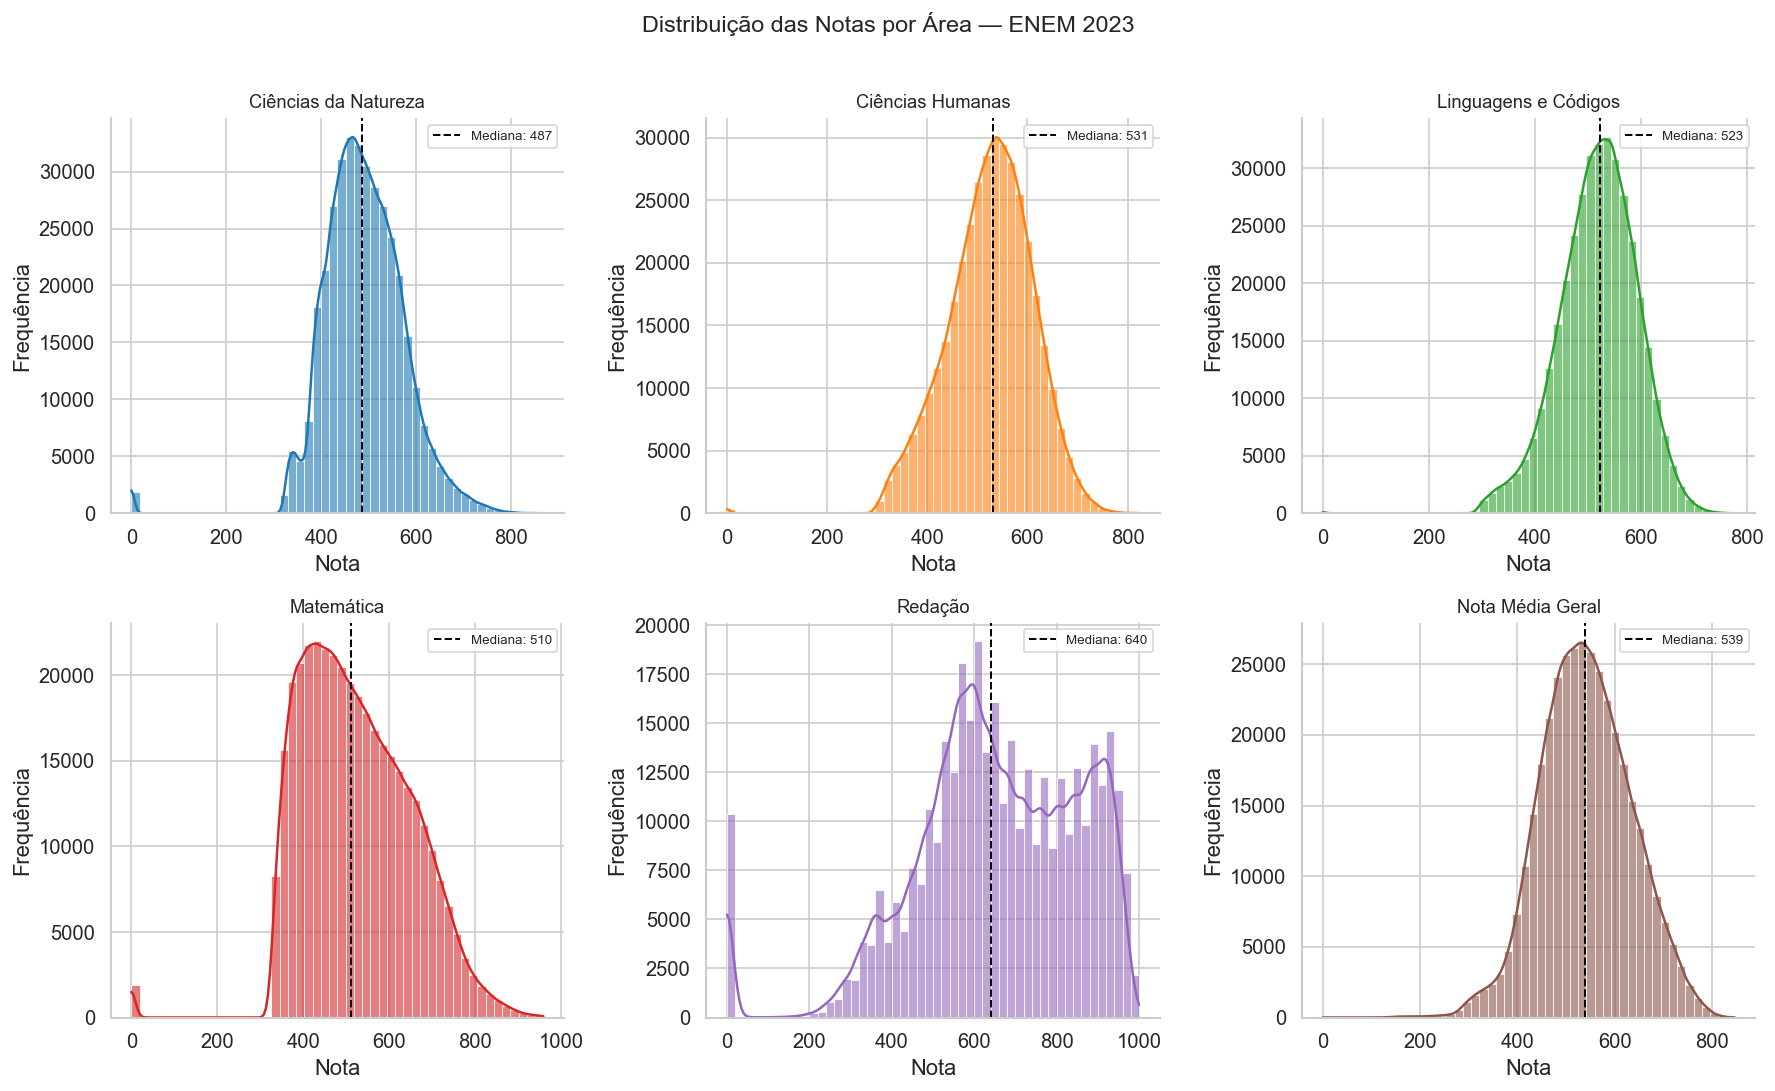

In [3]:
all_cols = NOTAS_COLS + ['NOTA_MEDIA']
col_labels_all = {**NOTAS_LABELS, 'NOTA_MEDIA': 'Nota Média Geral'}
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col, cor in zip(axes.flatten(), all_cols, cores):
    sns.histplot(data=df, x=col, ax=ax, bins=50, kde=True, color=cor, alpha=0.6)
    mediana = df[col].median()
    ax.axvline(mediana, color='black', linestyle='--', linewidth=1.2,
               label=f'Mediana: {mediana:.0f}')
    ax.set_title(col_labels_all[col], fontsize=11)
    ax.set_xlabel('Nota')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

fig.suptitle('Distribuição das Notas por Área — ENEM 2023', fontsize=14, y=1.01)
plt.tight_layout()
salvar_figura(fig, '02_histogramas_notas')
plt.show()

### 1.3 — Comparativo de distribuições (KDE sobreposto)

Colocar todas as áreas no mesmo eixo revela diferenças de dificuldade e spread entre as disciplinas.

Figura salva: ../reports/figures/02_kde_comparativo.png


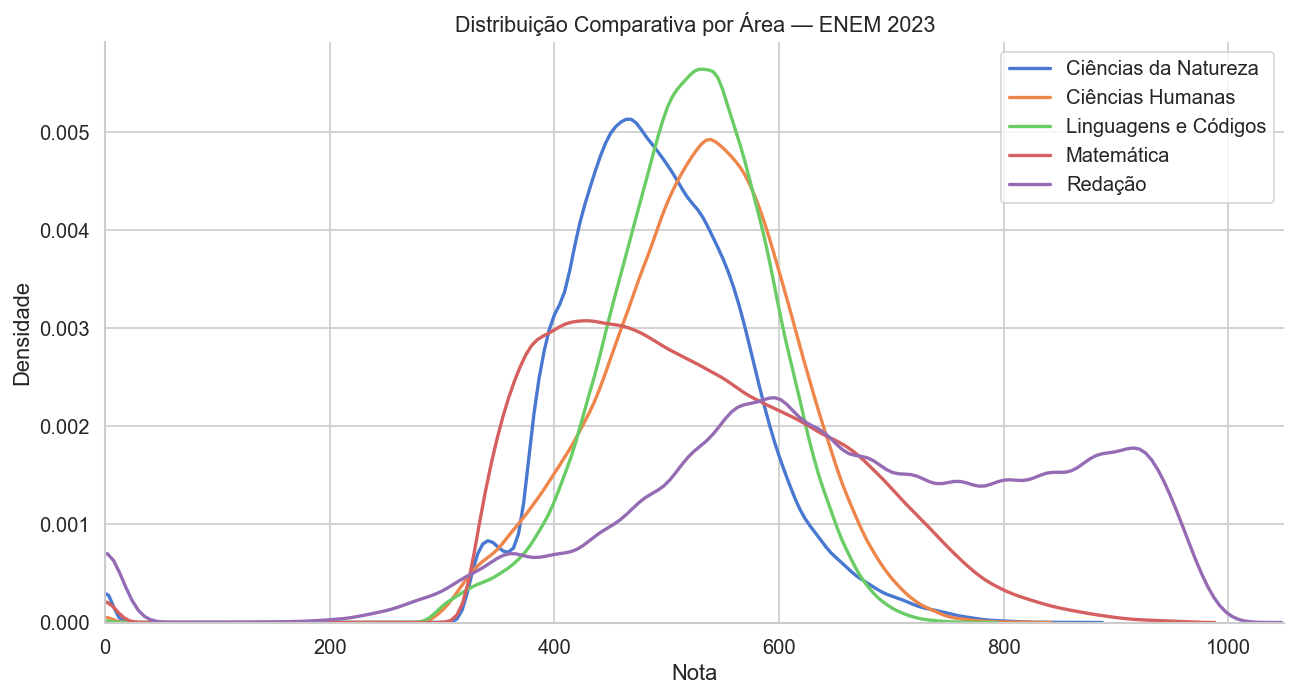

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

for col in NOTAS_COLS:
    sns.kdeplot(data=df, x=col, ax=ax, label=NOTAS_LABELS[col], linewidth=2)

ax.set_xlabel('Nota')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição Comparativa por Área — ENEM 2023', fontsize=13)
ax.set_xlim(0, 1050)
ax.legend()
plt.tight_layout()
salvar_figura(fig, '02_kde_comparativo')
plt.show()

### 1.4 — Boxplots por área

Boxplots evidenciam mediana, dispersão e outliers de forma compacta.

C:\Users\rodri\AppData\Local\Temp\ipykernel_11588\1632389644.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rodri\AppData\Local\Temp\ipykernel_11588\1632389644.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')


Figura salva: ../reports/figures/02_boxplots_notas.png


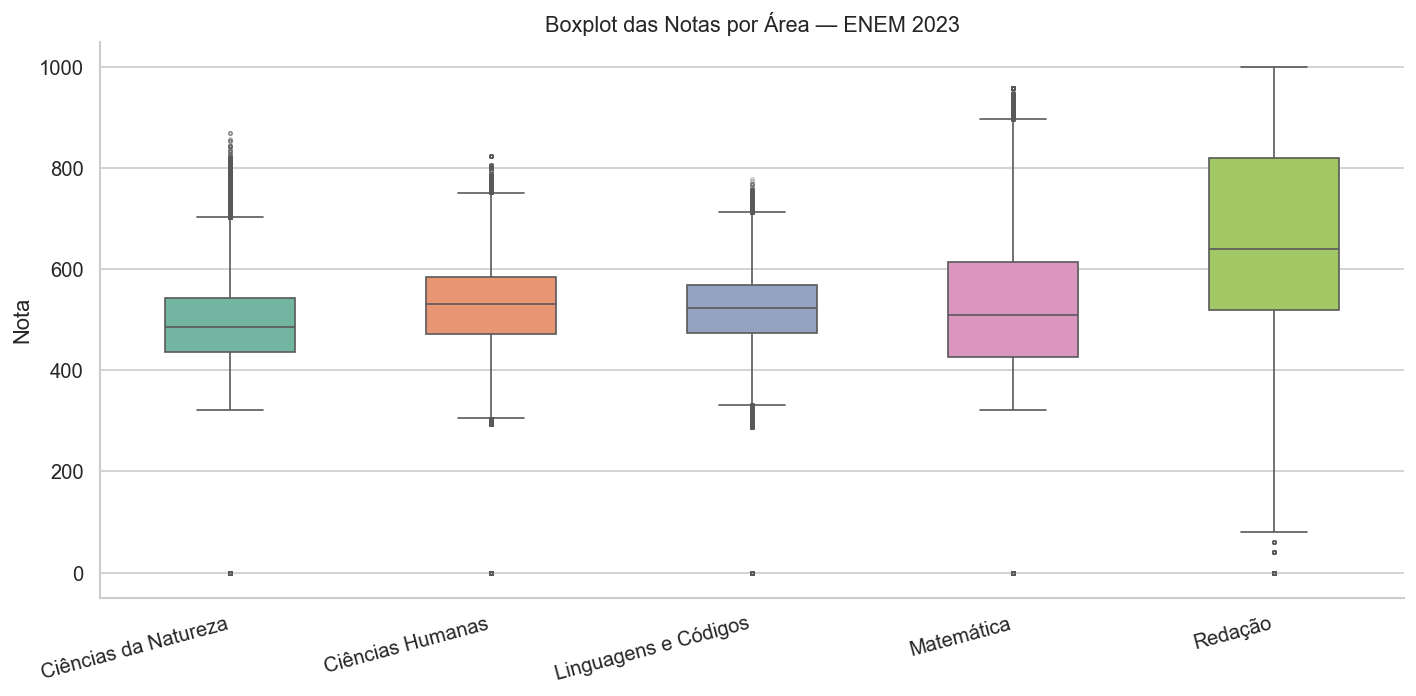

In [5]:
df_melted = df[NOTAS_COLS].melt(var_name='Area', value_name='Nota')
df_melted['Area'] = df_melted['Area'].map(NOTAS_LABELS)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_melted, x='Area', y='Nota', ax=ax,
    palette='Set2', width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.set_title('Boxplot das Notas por Área — ENEM 2023', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nota')
plt.tight_layout()
salvar_figura(fig, '02_boxplots_notas')
plt.show()

## 2. Variáveis Categóricas

### 2.1 — Tipo de escola e Sexo

Figura salva: ../reports/figures/02_escola_sexo.png


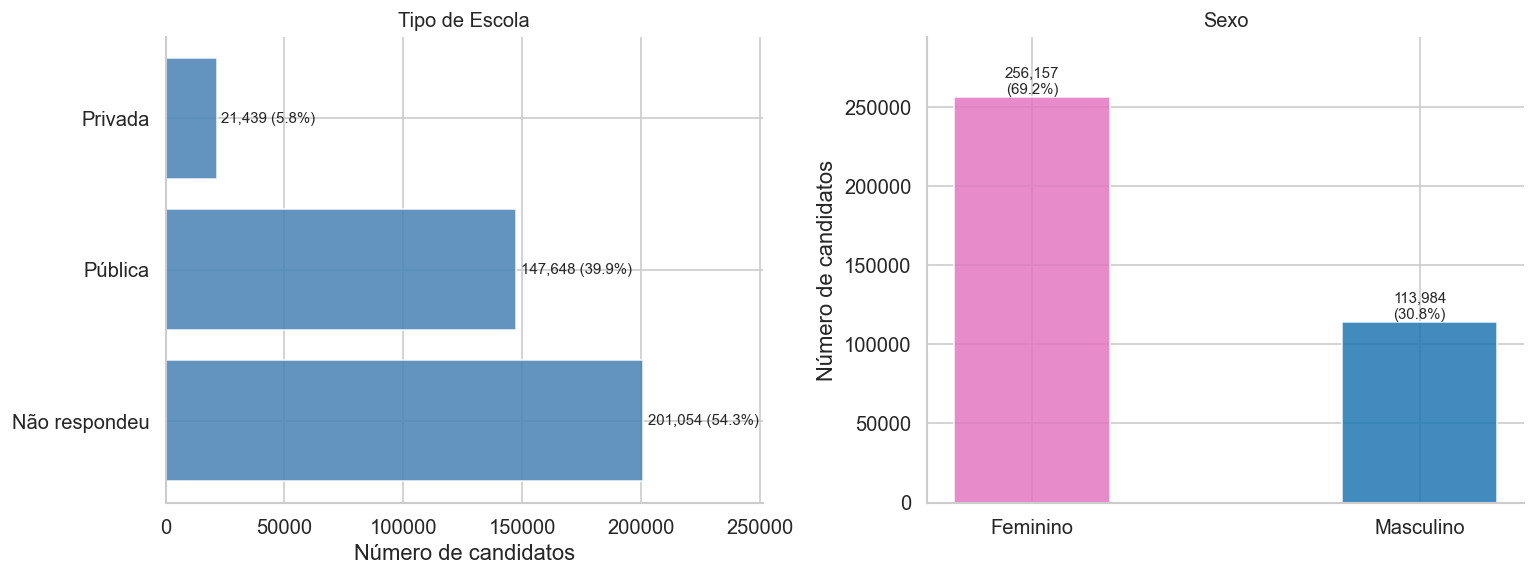

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tipo de escola
escola = df['TP_ESCOLA'].value_counts()
escola_pct = escola / escola.sum() * 100
bars = axes[0].barh(escola.index, escola.values, color='steelblue', alpha=0.85)
for bar, val, pct in zip(bars, escola.values, escola_pct.values):
    axes[0].text(val + escola.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
axes[0].set_xlabel('Número de candidatos')
axes[0].set_title('Tipo de Escola', fontsize=12)
axes[0].set_xlim(0, escola.max() * 1.25)

# Sexo
sexo = df['TP_SEXO'].value_counts()
sexo_pct = sexo / sexo.sum() * 100
bars2 = axes[1].bar(sexo.index, sexo.values,
                    color=['#e377c2', '#1f77b4'], alpha=0.85, width=0.4)
for bar, val, pct in zip(bars2, sexo.values, sexo_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + sexo.max() * 0.01,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)
axes[1].set_ylabel('Número de candidatos')
axes[1].set_title('Sexo', fontsize=12)
axes[1].set_ylim(0, sexo.max() * 1.15)

plt.tight_layout()
salvar_figura(fig, '02_escola_sexo')
plt.show()

### 2.2 — Cor/Raça autodeclarada

Figura salva: ../reports/figures/02_cor_raca.png


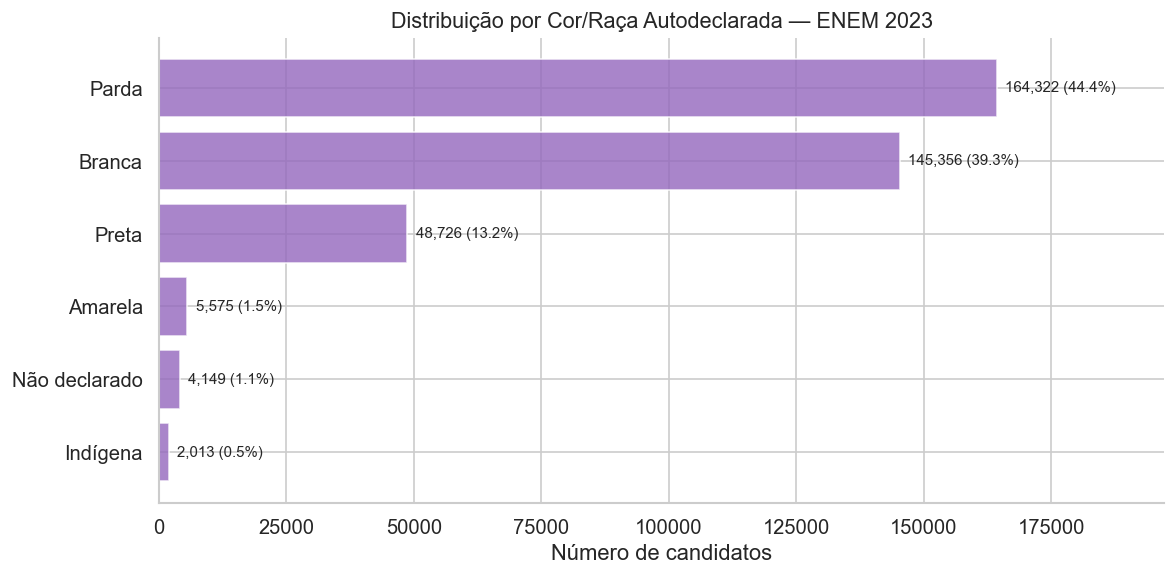

In [7]:
raca = df['TP_COR_RACA'].value_counts().sort_values()
raca_pct = raca / raca.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(raca.index, raca.values, color='#9467bd', alpha=0.8)
for bar, val, pct in zip(bars, raca.values, raca_pct.values):
    ax.text(val + raca.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Número de candidatos')
ax.set_title('Distribuição por Cor/Raça Autodeclarada — ENEM 2023', fontsize=13)
ax.set_xlim(0, raca.max() * 1.2)
plt.tight_layout()
salvar_figura(fig, '02_cor_raca')
plt.show()

### 2.3 — Faixa de renda familiar

As categorias Q006 seguem uma escala ordinal (A = sem renda → P = acima de R$ 39.600). Ordenar pelo código original revela o perfil de renda dos candidatos.

Figura salva: ../reports/figures/02_distribuicao_renda.png


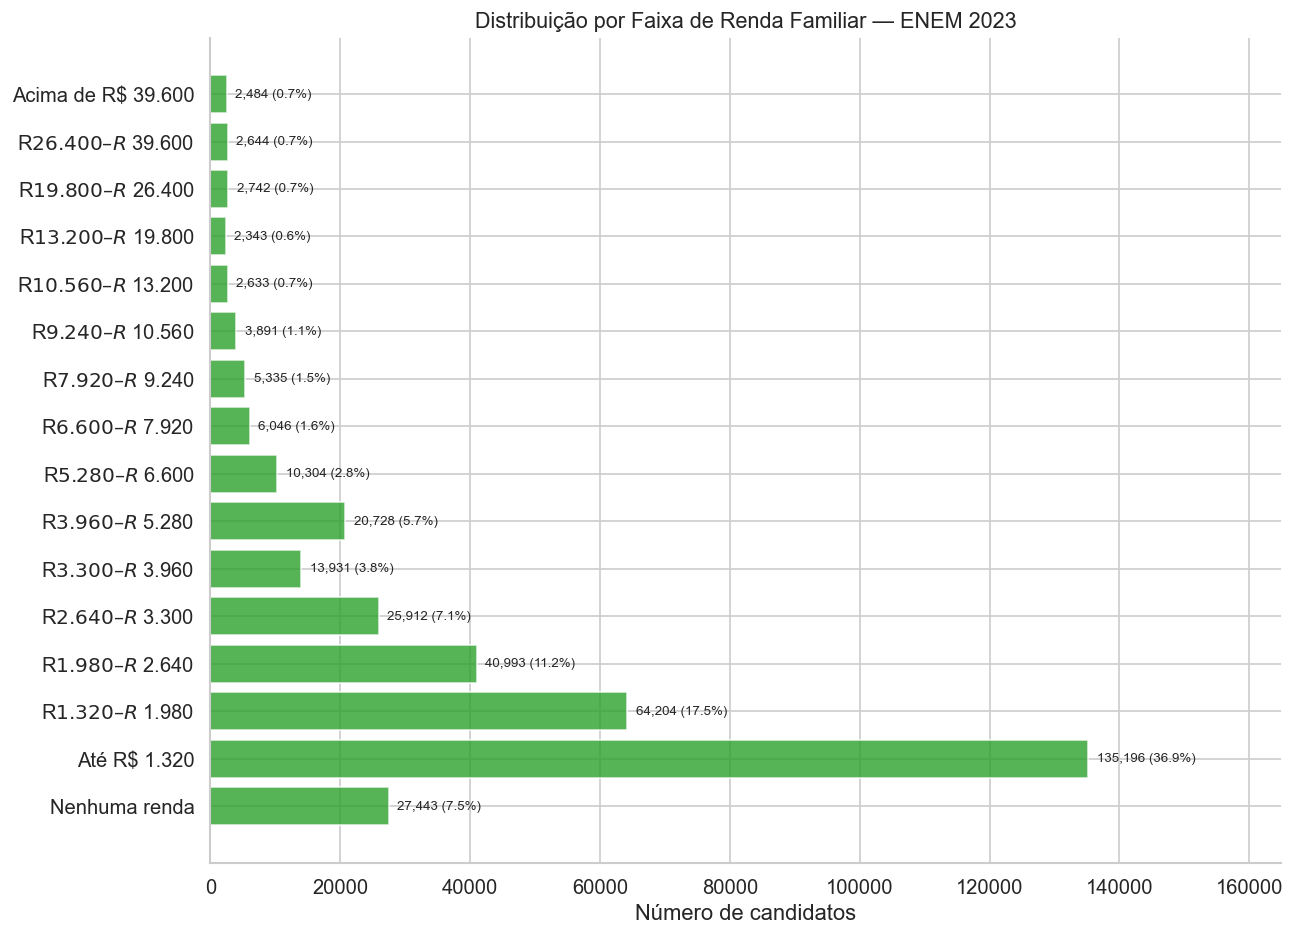

In [8]:
ordem_renda = list(MAPA_RENDA.values())
renda = df['Q006'].value_counts()
renda = renda.reindex([r for r in ordem_renda if r in renda.index])
renda_pct = renda / renda.sum() * 100

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(renda.index, renda.values, color='#2ca02c', alpha=0.8)
for bar, val, pct in zip(bars, renda.values, renda_pct.values):
    ax.text(val + renda.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Número de candidatos')
ax.set_title('Distribuição por Faixa de Renda Familiar — ENEM 2023', fontsize=13)
ax.set_xlim(0, renda.max() * 1.22)
plt.tight_layout()
salvar_figura(fig, '02_distribuicao_renda')
plt.show()

### 2.4 — Ranking de estados por nota média

C:\Users\rodri\AppData\Local\Temp\ipykernel_11588\1202937961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nota_uf = df.groupby('SG_UF_PROVA')['NOTA_MEDIA'].mean().sort_values(ascending=True)


Figura salva: ../reports/figures/02_ranking_uf.png


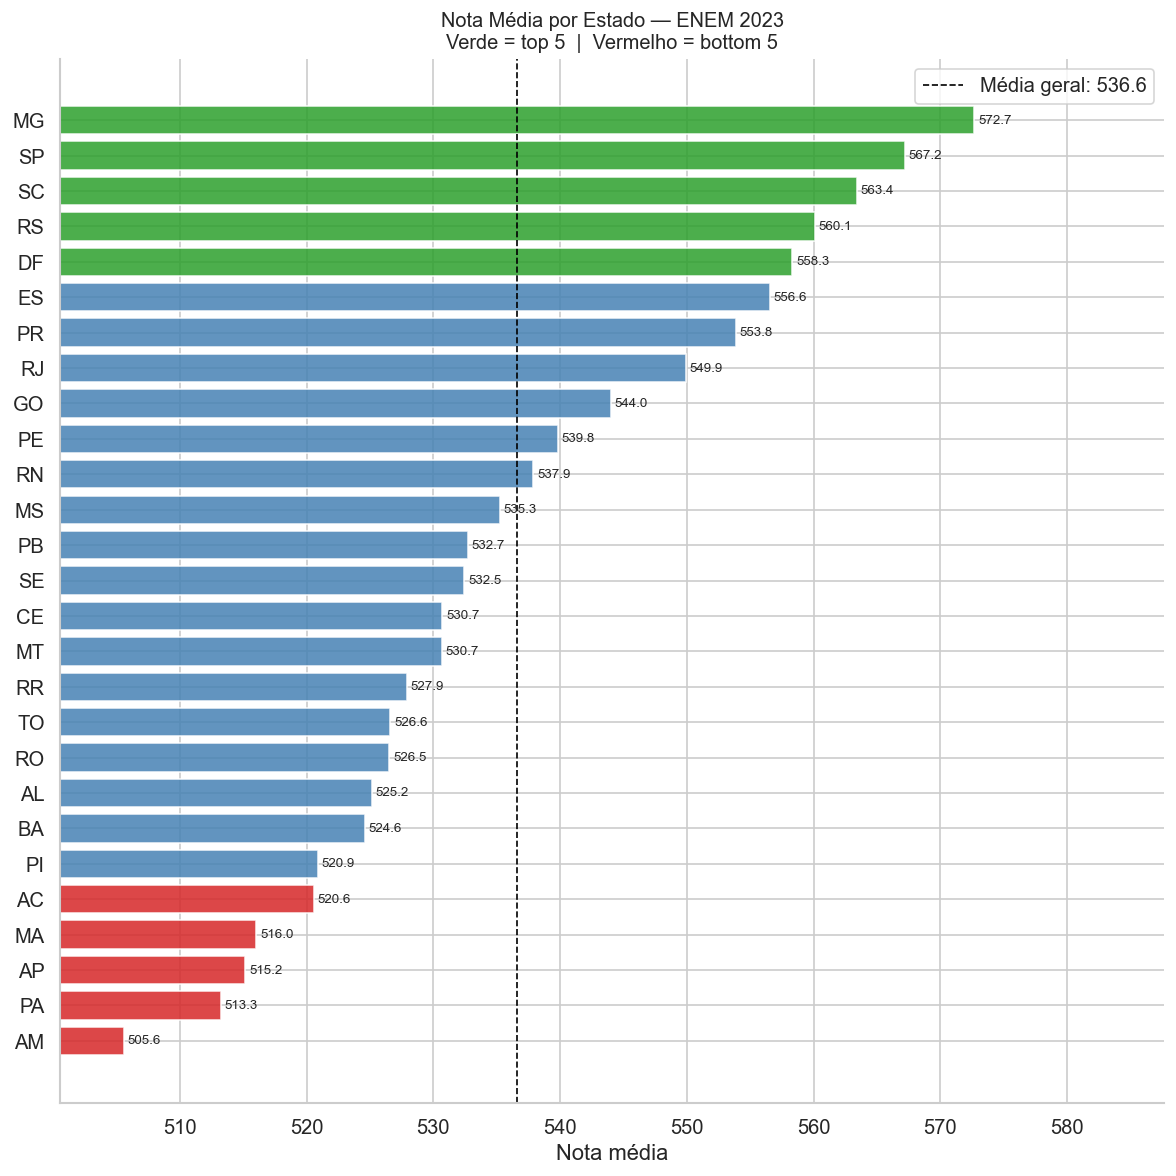

In [9]:
nota_uf = df.groupby('SG_UF_PROVA')['NOTA_MEDIA'].mean().sort_values(ascending=True)
media_geral = nota_uf.mean()

top5 = set(nota_uf.tail(5).index)
bot5 = set(nota_uf.head(5).index)
cores_uf = ['#d62728' if uf in bot5 else '#2ca02c' if uf in top5 else 'steelblue'
            for uf in nota_uf.index]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(nota_uf.index, nota_uf.values, color=cores_uf, alpha=0.85)
for bar, val in zip(bars, nota_uf.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=8)

ax.axvline(media_geral, color='black', linestyle='--', linewidth=1,
           label=f'Média geral: {media_geral:.1f}')
ax.set_xlabel('Nota média')
ax.set_title(
    'Nota Média por Estado — ENEM 2023\n'
    'Verde = top 5  |  Vermelho = bottom 5',
    fontsize=12
)
ax.legend()
ax.set_xlim(nota_uf.min() - 5, nota_uf.max() + 15)
plt.tight_layout()
salvar_figura(fig, '02_ranking_uf')
plt.show()

## 3. Principais Observações

A amostra limpa analisada neste notebook contém **370.141 candidatos**.

| Variável | Observação |
|---|---|
| Nota média geral | Média de **541,6 pts** e mediana de **538,8 pts**, indicando distribuição levemente assimétrica à direita. |
| Matemática | Maior dispersão entre as provas objetivas: média de **524,2 pts**, mediana de **510,1 pts** e desvio padrão de **127,0 pts**. |
| Redação | Maior média entre as áreas: **647,5 pts**, com mediana de **640,0 pts**; a distribuição é mais ampla por usar escala de 0 a 1000. |
| Escola | **54,3%** aparecem como `Não respondeu`; entre os que informaram escola, **87,3%** são de escola pública e **12,7%** de escola privada. |
| Sexo | Predomínio feminino: **256.157 candidatas (69,2%)** contra **113.984 candidatos (30,8%)**. |
| Cor/Raça | Os maiores grupos são **Parda (44,4%)**, **Branca (39,3%)** e **Preta (13,2%)**. |
| Renda | As faixas até **R$ 1.980** concentram **226.843 candidatos (61,3%)**; a maior faixa isolada é `Até R$ 1.320`, com **36,9%**. |
| Estado | Variação de **67,1 pts** entre o maior e o menor desempenho médio: **MG (572,7 pts)** no topo e **AM (505,6 pts)** na base. |

**Próximo passo:** `03_analise_bivariada.ipynb` — cruzamentos entre desempenho, renda, escola, raça e sexo.